# Pair Performance Analysis

This notebook analyzes the profitability of individual cointegrated stock pairs from the multi-pair statistical arbitrage backtest.

Objectives:

1. Rank pairs by profitability
2. Identify top performing pairs
3. Identify worst performing pairs
4. Visualize profit contribution of pairs
5. Compute summary statistics
6. Save sorted pair performance

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Pair Performance Data

This file was generated in the previous notebook during the multi-pair backtesting step.
It contains the profit generated by each trading pair.

In [2]:
# Load pair performance data

pair_df = pd.read_csv("../data/processed/pair_performance.csv")

pair_df.head()

,pair,profit
0,"('APOLLOHOSP.NS', 'ULTRACEMCO.NS')",3693.901855
1,"('EICHERMOT.NS', 'MARUTI.NS')",1715.404297
2,"('BRITANNIA.NS', 'LT.NS')",1345.148438
3,"('BRITANNIA.NS', 'SUNPHARMA.NS')",1183.976929
4,"('BRITANNIA.NS', 'ULTRACEMCO.NS')",1139.236816


## Sort Pairs by Profit

We rank trading pairs based on total profit generated during the backtest.

In [3]:
# Sort pairs by profitability

pair_df = pair_df.sort_values(by="profit", ascending=False)

pair_df.head(10)

,pair,profit
0,"('APOLLOHOSP.NS', 'ULTRACEMCO.NS')",3693.901855
1,"('EICHERMOT.NS', 'MARUTI.NS')",1715.404297
2,"('BRITANNIA.NS', 'LT.NS')",1345.148438
3,"('BRITANNIA.NS', 'SUNPHARMA.NS')",1183.976929
4,"('BRITANNIA.NS', 'ULTRACEMCO.NS')",1139.236816
5,"('M&M.NS', 'MARUTI.NS')",1112.954697
6,"('SUNPHARMA.NS', 'ULTRACEMCO.NS')",1109.217651
7,"('BPCL.NS', 'HEROMOTOCO.NS')",982.379547
8,"('ADANIPORTS.NS', 'CIPLA.NS')",921.495331
9,"('HCLTECH.NS', 'ULTRACEMCO.NS')",919.224365


## Top Performing Pairs

Display the most profitable trading pairs

In [4]:
# Top 10 performing pairs

top_pairs = pair_df.head(10)

print("Top performing pairs:")
top_pairs

Top performing pairs:


,pair,profit
0,"('APOLLOHOSP.NS', 'ULTRACEMCO.NS')",3693.901855
1,"('EICHERMOT.NS', 'MARUTI.NS')",1715.404297
2,"('BRITANNIA.NS', 'LT.NS')",1345.148438
3,"('BRITANNIA.NS', 'SUNPHARMA.NS')",1183.976929
4,"('BRITANNIA.NS', 'ULTRACEMCO.NS')",1139.236816
5,"('M&M.NS', 'MARUTI.NS')",1112.954697
6,"('SUNPHARMA.NS', 'ULTRACEMCO.NS')",1109.217651
7,"('BPCL.NS', 'HEROMOTOCO.NS')",982.379547
8,"('ADANIPORTS.NS', 'CIPLA.NS')",921.495331
9,"('HCLTECH.NS', 'ULTRACEMCO.NS')",919.224365


## Worst Performing Pairs

Display the least profitable trading pairs

In [5]:
# Worst 10 performing pairs

worst_pairs = pair_df.tail(10)

print("Worst performing pairs:")
worst_pairs

Worst performing pairs:


,pair,profit
93,"('APOLLOHOSP.NS', 'TECHM.NS')",0.000000
94,"('AXISBANK.NS', 'TITAN.NS')",0.000000
95,"('BAJAJFINSV.NS', 'KOTAKBANK.NS')",0.000000
96,"('GRASIM.NS', 'HINDALCO.NS')",0.000000
97,"('GRASIM.NS', 'TATASTEEL.NS')",0.000000
98,"('HDFCBANK.NS', 'ICICIBANK.NS')",0.000000
99,"('KOTAKBANK.NS', 'RELIANCE.NS')",0.000000
100,"('KOTAKBANK.NS', 'TATACONSUM.NS')",0.000000
101,"('SBILIFE.NS', 'TITAN.NS')",0.000000
102,"('BEL.NS', 'EICHERMOT.NS')",-506.164978


## Profit Distribution Across  Top Pairs

We visulize profit contribution of the top performing pairs

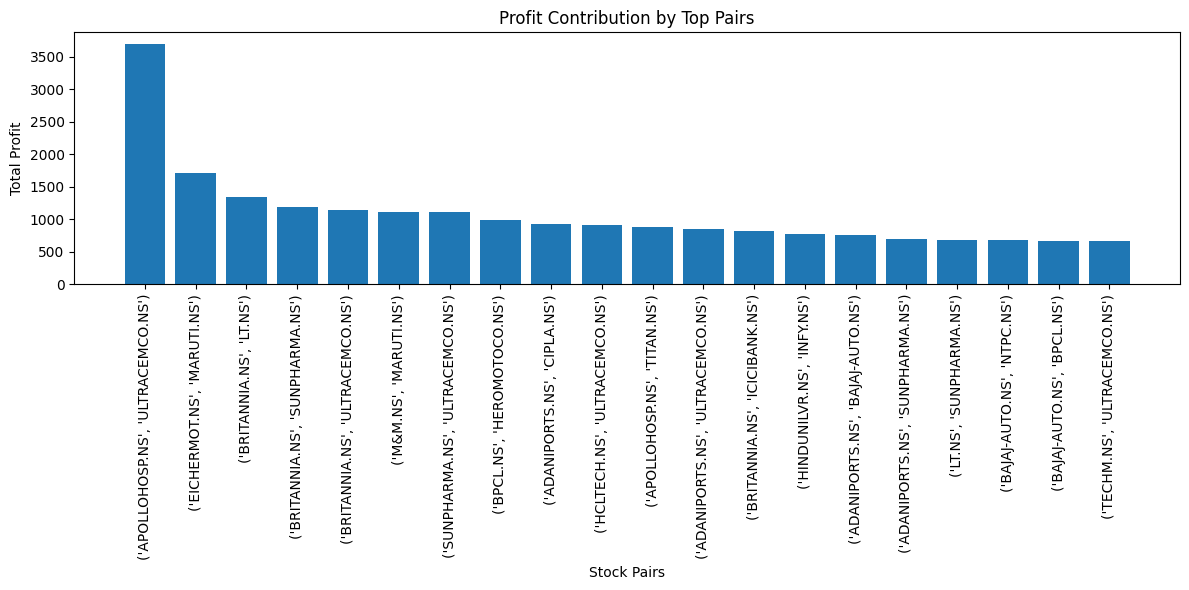

In [6]:
# Plot profit contribution of top pairs

top_plot = pair_df.head(20)

plt.figure(figsize=(12,6))

plt.bar(top_plot["pair"], top_plot["profit"])

plt.xticks(rotation=90)

plt.title("Profit Contribution by Top Pairs")
plt.xlabel("Stock Pairs")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.savefig("../reports/pair_profit_distribution.png")
plt.show()

## Profit Distribution of Trading Pairs

This histogram shows how profits are distributed across all trading pairs.
It helps identify whether profits come from a few pairs or many pairs.

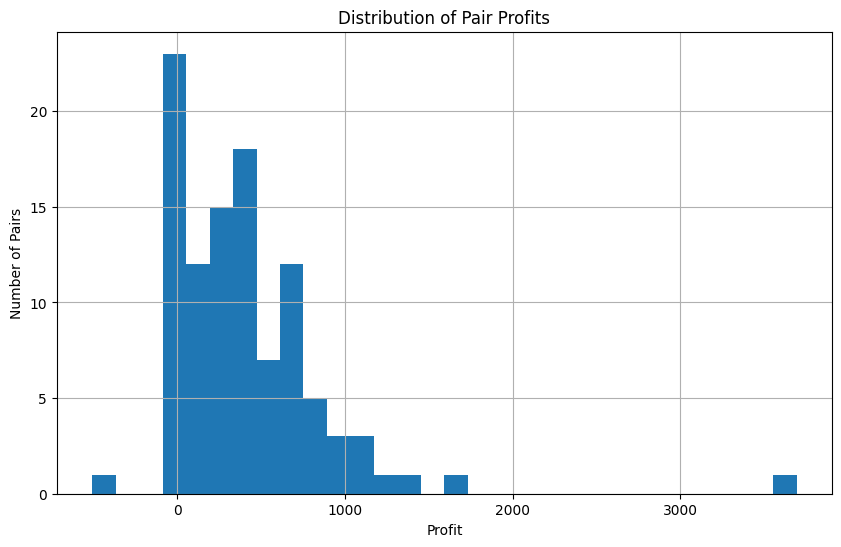

In [7]:
# Profit distribution histogram

plt.figure(figsize=(10,6))

plt.hist(pair_df["profit"], bins=30)

plt.title("Distribution of Pair Profits")
plt.xlabel("Profit")
plt.ylabel("Number of Pairs")

plt.grid(True)
plt.savefig("../reports/pair_profit_histogram.png")

plt.show()

## Cumulative Profit Contribution

This plot shows how cumulative profit grows as we include more trading pairs.

It helps identify whether a small number of pairs generate most of the portfolio profit.

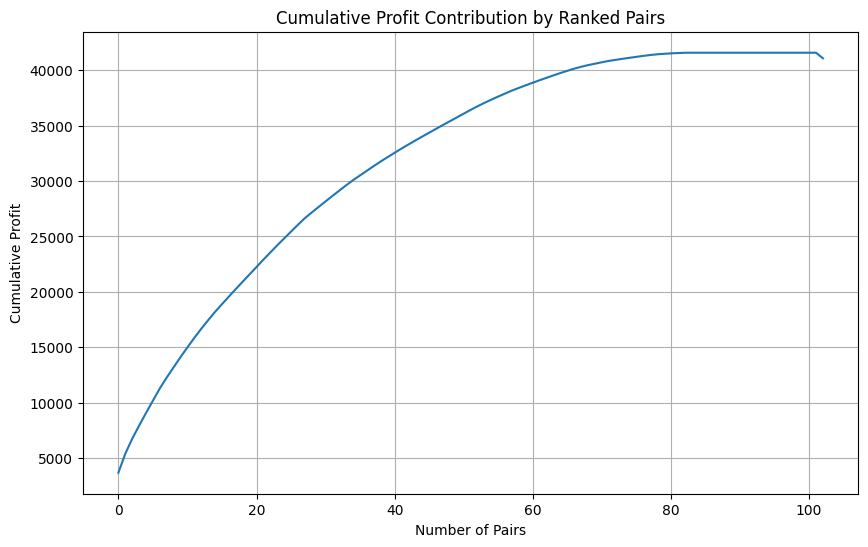

In [8]:
# Compute cumulative profit contribution

pair_df_sorted = pair_df.sort_values(by="profit", ascending=False)

cumulative_profit = pair_df_sorted["profit"].cumsum()

plt.figure(figsize=(10,6))

plt.plot(cumulative_profit)

plt.title("Cumulative Profit Contribution by Ranked Pairs")
plt.xlabel("Number of Pairs")
plt.ylabel("Cumulative Profit")

plt.grid(True)
plt.savefig("../reports/cumulative_pair_profit.png")
plt.show()

## Profit Statistics

Summary statistics of pair profitability

In [9]:
# Ensure profit column is numeric

pair_df["profit"] = pd.to_numeric(pair_df["profit"], errors="coerce")

print("Average pair profit:", pair_df["profit"].mean())
print("Median pair profit:", pair_df["profit"].median())
print("Max pair profit:", pair_df["profit"].max())
print("Min pair profit:", pair_df["profit"].min())
print("Profit std:", pair_df["profit"].std())

top20_share = pair_df.head(20)["profit"].sum() / pair_df["profit"].sum()

print("Top 20 pairs profit share:", top20_share)

Average pair profit: 398.6895923058963
Median pair profit: 339.4418945312499
Max pair profit: 3693.90185546875
Min pair profit: -506.16497802734375
Profit std: 486.21931295721964
Top 20 pairs profit share: 0.5256882563288119


## Save Sorted Pair Performance

Save the ranked pair performance for further analysis

In [10]:

pair_df["profit"] = pd.to_numeric(pair_df["profit"], errors="coerce")
pair_df=pair_df.dropna()
pair_df.to_csv("../data/processed/sorted_pair_performance.csv", index=False)
print("Sorted pair performance saved successfully")

Sorted pair performance saved successfully


## Summary

In this notebook we analyzed the profitability of trading pairs generated from the multi-pair statistical arbitrage strategy.

Key insights:

• Trading pairs were ranked by profitability  
• Top and worst performing pairs were identified  
• Profit distribution across pairs was visualized  
• Summary statistics of pair performance were computed  

These results help identify the most reliable trading relationships and guide the selection of pairs for further strategy optimization.